# Tuning MPC weights with CEM and batched cuPIQP

Tuning MPC cost weights is normally hand-rolled and painful: pick weights, simulate, eyeball the trajectory, tweak, repeat. This notebook hands the job to the **Cross-Entropy Method (CEM)**, which keeps a Gaussian over the weights, samples a population each iteration, and refits it to the best-scoring **elites** (details in the next section).

Sampling a population requires to solve a batch of optimal control problems, which is suitable to be solved with cuPIQP. In this notebook we will show it through a simple double-integrator example.

## How the Cross-Entropy Method works

CEM is an iterative, sampling-based optimizer for a (possibly black-box, non-differentiable)
objective $J(\theta)$ with $\theta \in \mathbb{R}^n$. Instead of moving a single point along a
gradient, it maintains a **search distribution** $p(\theta;\mathbf v)$ and updates its
parameters $\mathbf v$ so that samples concentrate where $J$ is small. We use the standard
choice: a Gaussian with diagonal covariance, $\mathbf v=(\mu,\sigma^2)$.

**The idea.** Treat "find a good $\theta$" as the *rare event* $\{J(\theta)\le\gamma\}$ for a
low threshold $\gamma$. The distribution that best samples that event is the current density
conditioned on the elite set; CEM picks the Gaussian closest to it in **Kullback-Leibler
(cross-entropy) divergence**. For an exponential family like the Gaussian that projection has
a closed form — it is exactly the **maximum-likelihood fit to the elite samples**. So the
abstract "minimize cross-entropy" step becomes the very concrete "fit a Gaussian to the best
samples," which is the entire algorithm.

**One iteration.** With population size $\lambda$ and elite fraction $\rho$ (so
$\mu_e=\lceil\rho\lambda\rceil$ elites), draw a population, keep the lowest-scoring elites
$\mathcal E$, and refit the Gaussian to them by maximum likelihood:

$$
\theta_i \sim \mathcal N\!\bigl(\mu,\operatorname{diag}(\sigma^2)\bigr),\quad i=1,\dots,\lambda
$$

$$
\mathcal E=\bigl\{\text{the } \mu_e \text{ samples with smallest } J(\theta_i)\bigr\}
$$

$$
\mu_{\mathcal E} = \frac{1}{\mu_e}\sum_{i\in\mathcal E}\theta_i,
\qquad
\sigma^2_{\mathcal E} = \frac{1}{\mu_e}\sum_{i\in\mathcal E}(\theta_i-\mu_{\mathcal E})\odot(\theta_i-\mu_{\mathcal E}),
$$

where $\odot$ is the elementwise product (a diagonal covariance means a per-coordinate
variance), and the elite variance $\sigma^2_{\mathcal E}$ is taken about the elite mean
$\mu_{\mathcal E}$.

**Two practical refinements** (both used below). Rather than overwrite $(\mu,\sigma^2)$ with
the raw elite fit, we update them through:

- *Smoothing.* Blend the fresh fit with the old parameters via an exponential moving average
  of rate $\alpha\in(0,1]$,
  $$\mu \leftarrow \alpha\,\mu_{\mathcal E}+(1-\alpha)\,\mu,\qquad
    \sigma^2 \leftarrow \alpha\,\sigma^2_{\mathcal E}+(1-\alpha)\,\sigma^2 + \varepsilon_t.$$
  This lowers the variance of the update so a single unlucky population cannot derail the search.
- *Noise floor.* The added term $\varepsilon_t\!\to\!0$ is a small, geometrically decaying
  variance kept each iteration. Without it the variance can collapse to zero and the search
  freezes at a mediocre point — a classic CEM failure mode ([Szita & Lőrincz, 2006](https://doi.org/10.1162/neco.2006.18.12.2936)).

Those four moves — **sample, rank, refit, smooth-with-noise-floor** — are the whole method,
and the next code cell implements exactly them. The symbols map directly to the code:
$\lambda=$ `popsize`, $\rho=$ `elite_frac` (so $\mu_e=$ `n_elite`), $\alpha=$ `smooth`, and
$\varepsilon_t=$ `noise0 * noise_decay**t`. Here $\theta$ is the (log-scale) MPC cost weights
and $J$ is the closed-loop performance index of a full rollout — so each evaluation
"$J(\theta_i)$" is one MPC simulation, and the whole population is scored in a single GPU
batch.

In [1]:
import numpy as np
import scipy.sparse as sp
import cupy as cp
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from cupyx.scipy.sparse import csr_matrix
from cupiqp import SparseSolver, UniformBatchedCsrMatrix

N, T, DT, U_MAX = 20, 60, 0.1, 1.5   # horizon, rollout length, timestep, input limit


def build_problem():
    # Double-integrator dynamics: x = [pos, vel], u = acceleration.
    Ad = np.array([[1.0, DT], [0.0, 1.0]])
    Bd = np.array([[0.5 * DT * DT], [DT]])

    # Decision vector z = [x_0, ..., x_N, u_0, ..., u_{N-1}] (states kept, not condensed).
    n_state = (N + 1) * 2
    n_var = n_state + N
    n_eq = (N + 1) * 2
    iu0 = n_state                                  # index of u_0 inside z

    # Equality constraints A z = b: x_0 = x_init and x_{k+1} = Ad x_k + Bd u_k.
    Ax = sp.kron(sp.eye(N + 1), -sp.eye(2)) + sp.kron(sp.eye(N + 1, k=-1), Ad)
    Bu = sp.kron(sp.vstack([sp.csr_matrix((1, N)), sp.eye(N)]), Bd)
    A = csr_matrix(sp.hstack([Ax, Bu]).tocsr())

    # Input limits as box bounds on z: states free (+/-inf), inputs in [-U_MAX, U_MAX].
    x_l = cp.concatenate([cp.full(n_state, -cp.inf), cp.full(N, -U_MAX)])
    x_u = cp.concatenate([cp.full(n_state,  cp.inf), cp.full(N,  U_MAX)])

    # Sinusoidal position reference (+ analytic velocity). windows[t] stacks the N future
    # targets [pos, vel] over the horizon at closed-loop step t; ref_pos[t] is the target now.
    steps = np.arange(T + N + 1)
    omega = 2 * np.pi / 5
    reference = np.column_stack([np.sin(omega * DT * steps),
                                 omega * np.cos(omega * DT * steps)])
    windows = reference[np.arange(T)[:, None] + np.arange(1, N + 1)].reshape(T, 2 * N)

    return {
        "Ad": cp.asarray(Ad), "Bd": cp.asarray(Bd.reshape(-1)),
        "A": A, "x_l": x_l, "x_u": x_u,
        "windows": cp.asarray(windows),            # (T, 2N) future references
        "ref_pos": cp.asarray(reference[:T, 0]),   # (T,)   current-time position ref
        "n_state": n_state, "n_dec": n_var, "n_eq": n_eq, "iu0": iu0,
        "P_indices": cp.arange(n_var, dtype=cp.int32),    # diagonal-P CSR pattern
        "P_indptr": cp.arange(n_var + 1, dtype=cp.int32),
    }


problem = build_problem()
print(f"sparse MPC: N={N}, T={T}, decision vars n={problem['n_dec']}, "
      f"equality constraints p={problem['n_eq']}, A nnz={problem['A'].nnz}")

sparse MPC: N=20, T=60, decision vars n=62, equality constraints p=42, A nnz=204


## Weights to be tuned
For simplicity, we fix the input weight as $R=1$ and constrain $Q$ to be a diagonal matrix such that $Q = [q_{pos}, 0; 0, q_{vel}]$, whose diagonal elements are the parameters to be tuned:

- `q_pos` — how aggressively the controller chases the position reference,
- `q_vel` — how strongly it penalizes velocity error (smoothness vs. responsiveness).

CEM minimizes a closed-loop **performance index** (tracking error with a small
actuator-effort term — gives the trade-off a well-defined interior optimum):

$$
J \;=\; \frac{1}{T}\sum_t \Bigl[(x_{pos, t} - x_{ref, t})^2 + w_{\text{eff}}\, u_t^2\Bigr].
$$

We still report headline **tracking RMSE** to the human.

In [2]:
class BatchedMPC:
    """Closed-loop MPC rollout for a whole population of weight vectors, in one batch."""

    def __init__(self, batch_size):
        self.B = batch_size
        self.solver = SparseSolver()
        self.solver.settings.eps_abs = 1e-8
        self.solver.settings.max_iter = 60
        self.solver.settings.verbose = False
        # The equality matrix is constant across candidates -- broadcast it once.
        A = problem["A"]
        self.A = UniformBatchedCsrMatrix(
            self.B, A.indices, A.indptr,
            cp.broadcast_to(A.data, (self.B, A.nnz)).copy(), shape=A.shape)
        self.initialized = False

    def rollout(self, weights, record=False):
        B, n_dec, n_eq, iu0 = self.B, problem["n_dec"], problem["n_eq"], problem["iu0"]
        w = cp.asarray(weights)                          # (B, 2) = [q_pos, q_vel]
        q = cp.tile(w, (1, N))                           # (B, 2N) per-stage state weights

        # Diagonal Hessian of (1/2) z^T P z: 0 on x_0, 2Q on x_1..x_N, 2R(=2) on the inputs.
        diagonal = cp.concatenate(
            [cp.zeros((B, 2)), 2.0 * q, cp.full((B, N), 2.0)], axis=1)
        P = UniformBatchedCsrMatrix(
            B, problem["P_indices"], problem["P_indptr"], diagonal, shape=(n_dec, n_dec))

        x = cp.zeros((B, 2))                             # true state [pos, vel]
        tracking_error = cp.zeros(B)
        effort = cp.zeros(B)
        positions, controls = [], []

        for t in range(T):
            # Linear tracking term and equality RHS (initial state) for this step.
            c = cp.concatenate(
                [cp.zeros((B, 2)), -2.0 * q * problem["windows"][t][None, :],
                 cp.zeros((B, N))], axis=1)
            b = cp.zeros((B, n_eq))
            b[:, :2] = -x

            if not self.initialized:                     # first solve ever: full setup
                self.solver.setup(P=P, c=c, A=self.A, b=b,
                                  x_l=problem["x_l"], x_u=problem["x_u"])
                self.initialized = True
            elif t == 0:                                 # new population: weights (P) changed
                self.solver.update(P=P, c=c, b=b)
            else:                                        # within a rollout: only ref + state move
                self.solver.update(c=c, b=b)
            self.solver.solve()

            u0 = cp.clip(self.solver.result.x[:, iu0], -U_MAX, U_MAX)
            tracking_error += (x[:, 0] - problem["ref_pos"][t]) ** 2
            effort += u0 ** 2
            if record:
                positions.append(x[:, 0].copy())
                controls.append(u0.copy())
            x = x @ problem["Ad"].T + u0[:, None] * problem["Bd"][None, :]  # true dynamics step

        score = cp.asnumpy((tracking_error + 0.01 * effort) / T)
        rmse = cp.asnumpy(cp.sqrt(tracking_error / T))
        if record:
            return score, rmse, cp.asnumpy(cp.stack(positions)), cp.asnumpy(cp.stack(controls))
        return score, rmse

## Training

In [3]:
class CEM:
    """Diagonal-Gaussian Cross-Entropy Method for minimization.

    sample_population() draws a population from the current Gaussian;
    update(fitness) refits it to the best `elite_frac` of the population with
    smoothing and a geometrically-decaying noise floor (so the variance does
    not collapse too early).
    """

    def __init__(self, x0, sigma0, popsize, elite_frac=0.25,
                 smooth=0.7, noise0=0.05, noise_decay=0.9, seed=0):
        self.mean        = np.asarray(x0, dtype=float)
        self.var         = np.full(len(x0), float(sigma0) ** 2)
        self.lam         = popsize
        self.n_elite     = max(2, int(round(elite_frac * popsize)))
        self.smooth      = smooth        # EMA weight on the fresh elite estimate
        self.noise0      = noise0        # extra variance added at iteration 0
        self.noise_decay = noise_decay   # geometric decay of that extra variance
        self.rng         = np.random.default_rng(seed)
        self.gen         = 0

    def sample_population(self):
        # Draw `lam` candidates from the current diagonal Gaussian.
        self._theta = self.mean + np.sqrt(self.var) * self.rng.standard_normal((self.lam, len(self.mean)))
        return self._theta

    def update(self, fitness):
        # Refit the Gaussian to the best-scoring elite fraction (lowest fitness).
        elite = self._theta[np.argsort(fitness)[: self.n_elite]]
        a = self.smooth
        self.mean = a * elite.mean(axis=0) + (1.0 - a) * self.mean
        self.var = (a * elite.var(axis=0) + (1.0 - a) * self.var
                    + self.noise0 * self.noise_decay ** self.gen)
        self.gen += 1


# log-space search coordinates theta -> positive weights (q_pos, q_vel), clipped for stability
THETA_CLIP = (-4.0, 7.0)
def weights_from_theta(theta):
    return np.exp(np.clip(theta, *THETA_CLIP))

In [4]:
POPULATION, ITERATIONS = 64, 30
cem = CEM(x0=[0.0, 0.0], sigma0=1.0, popsize=POPULATION, seed=0)   # search over [log q_pos, log q_vel]
mpc = BatchedMPC(POPULATION)
history = []

print(f"CEM MPC tuning | population={POPULATION} | iterations={ITERATIONS}")
print(f"{'iter':>4}  {'best RMSE':>10}  {'mean RMSE':>10}   mean weights (q_pos, q_vel)")

for generation in range(ITERATIONS):
    theta = cem.sample_population()
    weights = weights_from_theta(theta)               # positive (q_pos, q_vel)
    score, rmse = mpc.rollout(weights)                # one batched closed-loop rollout
    cem.update(score)                                 # refit the search distribution to the elites

    wmean = weights_from_theta(cem.mean)
    history.append([rmse.min(), rmse.mean(), *wmean])
    if generation % 2 == 0:
        print(f"{generation:>4}  {rmse.min():>10.4f}  {rmse.mean():>10.4f}   "
        	f"({wmean[0]:8.2f}, {wmean[1]:8.2f})")

history = np.asarray(history)
learned_weights = weights_from_theta(cem.mean)

print(f"\nfinished: {ITERATIONS} x {POPULATION} = {ITERATIONS * POPULATION * T:,} MPC QPs, all batched.")
print(f"learned weights (q_pos, q_vel): ({learned_weights[0]:.2f}, {learned_weights[1]:.2f})")

CEM MPC tuning | population=64 | iterations=30
iter   best RMSE   mean RMSE   mean weights (q_pos, q_vel)
   0      0.2213      0.3741   (    2.08,     1.94)
   2      0.1781      0.2696   (    5.35,     3.14)
   4      0.1794      0.2135   (   10.56,     4.21)
   6      0.1685      0.1883   (   16.65,     4.63)
   8      0.1635      0.1758   (   23.45,     5.01)
  10      0.1593      0.1663   (   34.24,     4.76)
  12      0.1562      0.1604   (   48.83,     3.87)
  14      0.1535      0.1571   (   65.61,     3.81)
  16      0.1527      0.1545   (   85.47,     3.58)
  18      0.1526      0.1534   (   92.43,     3.86)
  20      0.1525      0.1532   (   92.77,     3.97)
  22      0.1525      0.1533   (   93.07,     4.14)
  24      0.1525      0.1533   (   92.87,     4.35)
  26      0.1526      0.1532   (   93.44,     4.40)
  28      0.1527      0.1532   (   93.38,     4.44)

finished: 30 x 64 = 115,200 MPC QPs, all batched.
learned weights (q_pos, q_vel): (93.10, 4.41)


## Results

We replay the closed-loop rollout for the initial weights and the learned weights:

- learning curve — best and population-mean tracking RMSE per CEM iteration;
- weight evolution — how the distribution-mean `q_pos` and `q_vel` move as the search
  converges (the input weight `r` stays fixed at 1);
- tracking — closed-loop position against the reference, before vs. after tuning;
- control input — the applied acceleration, held piecewise-constant over each step and
  kept within the box limit $|u|\le 1.5$.

The learned weights track the reference better while respecting the input limit.

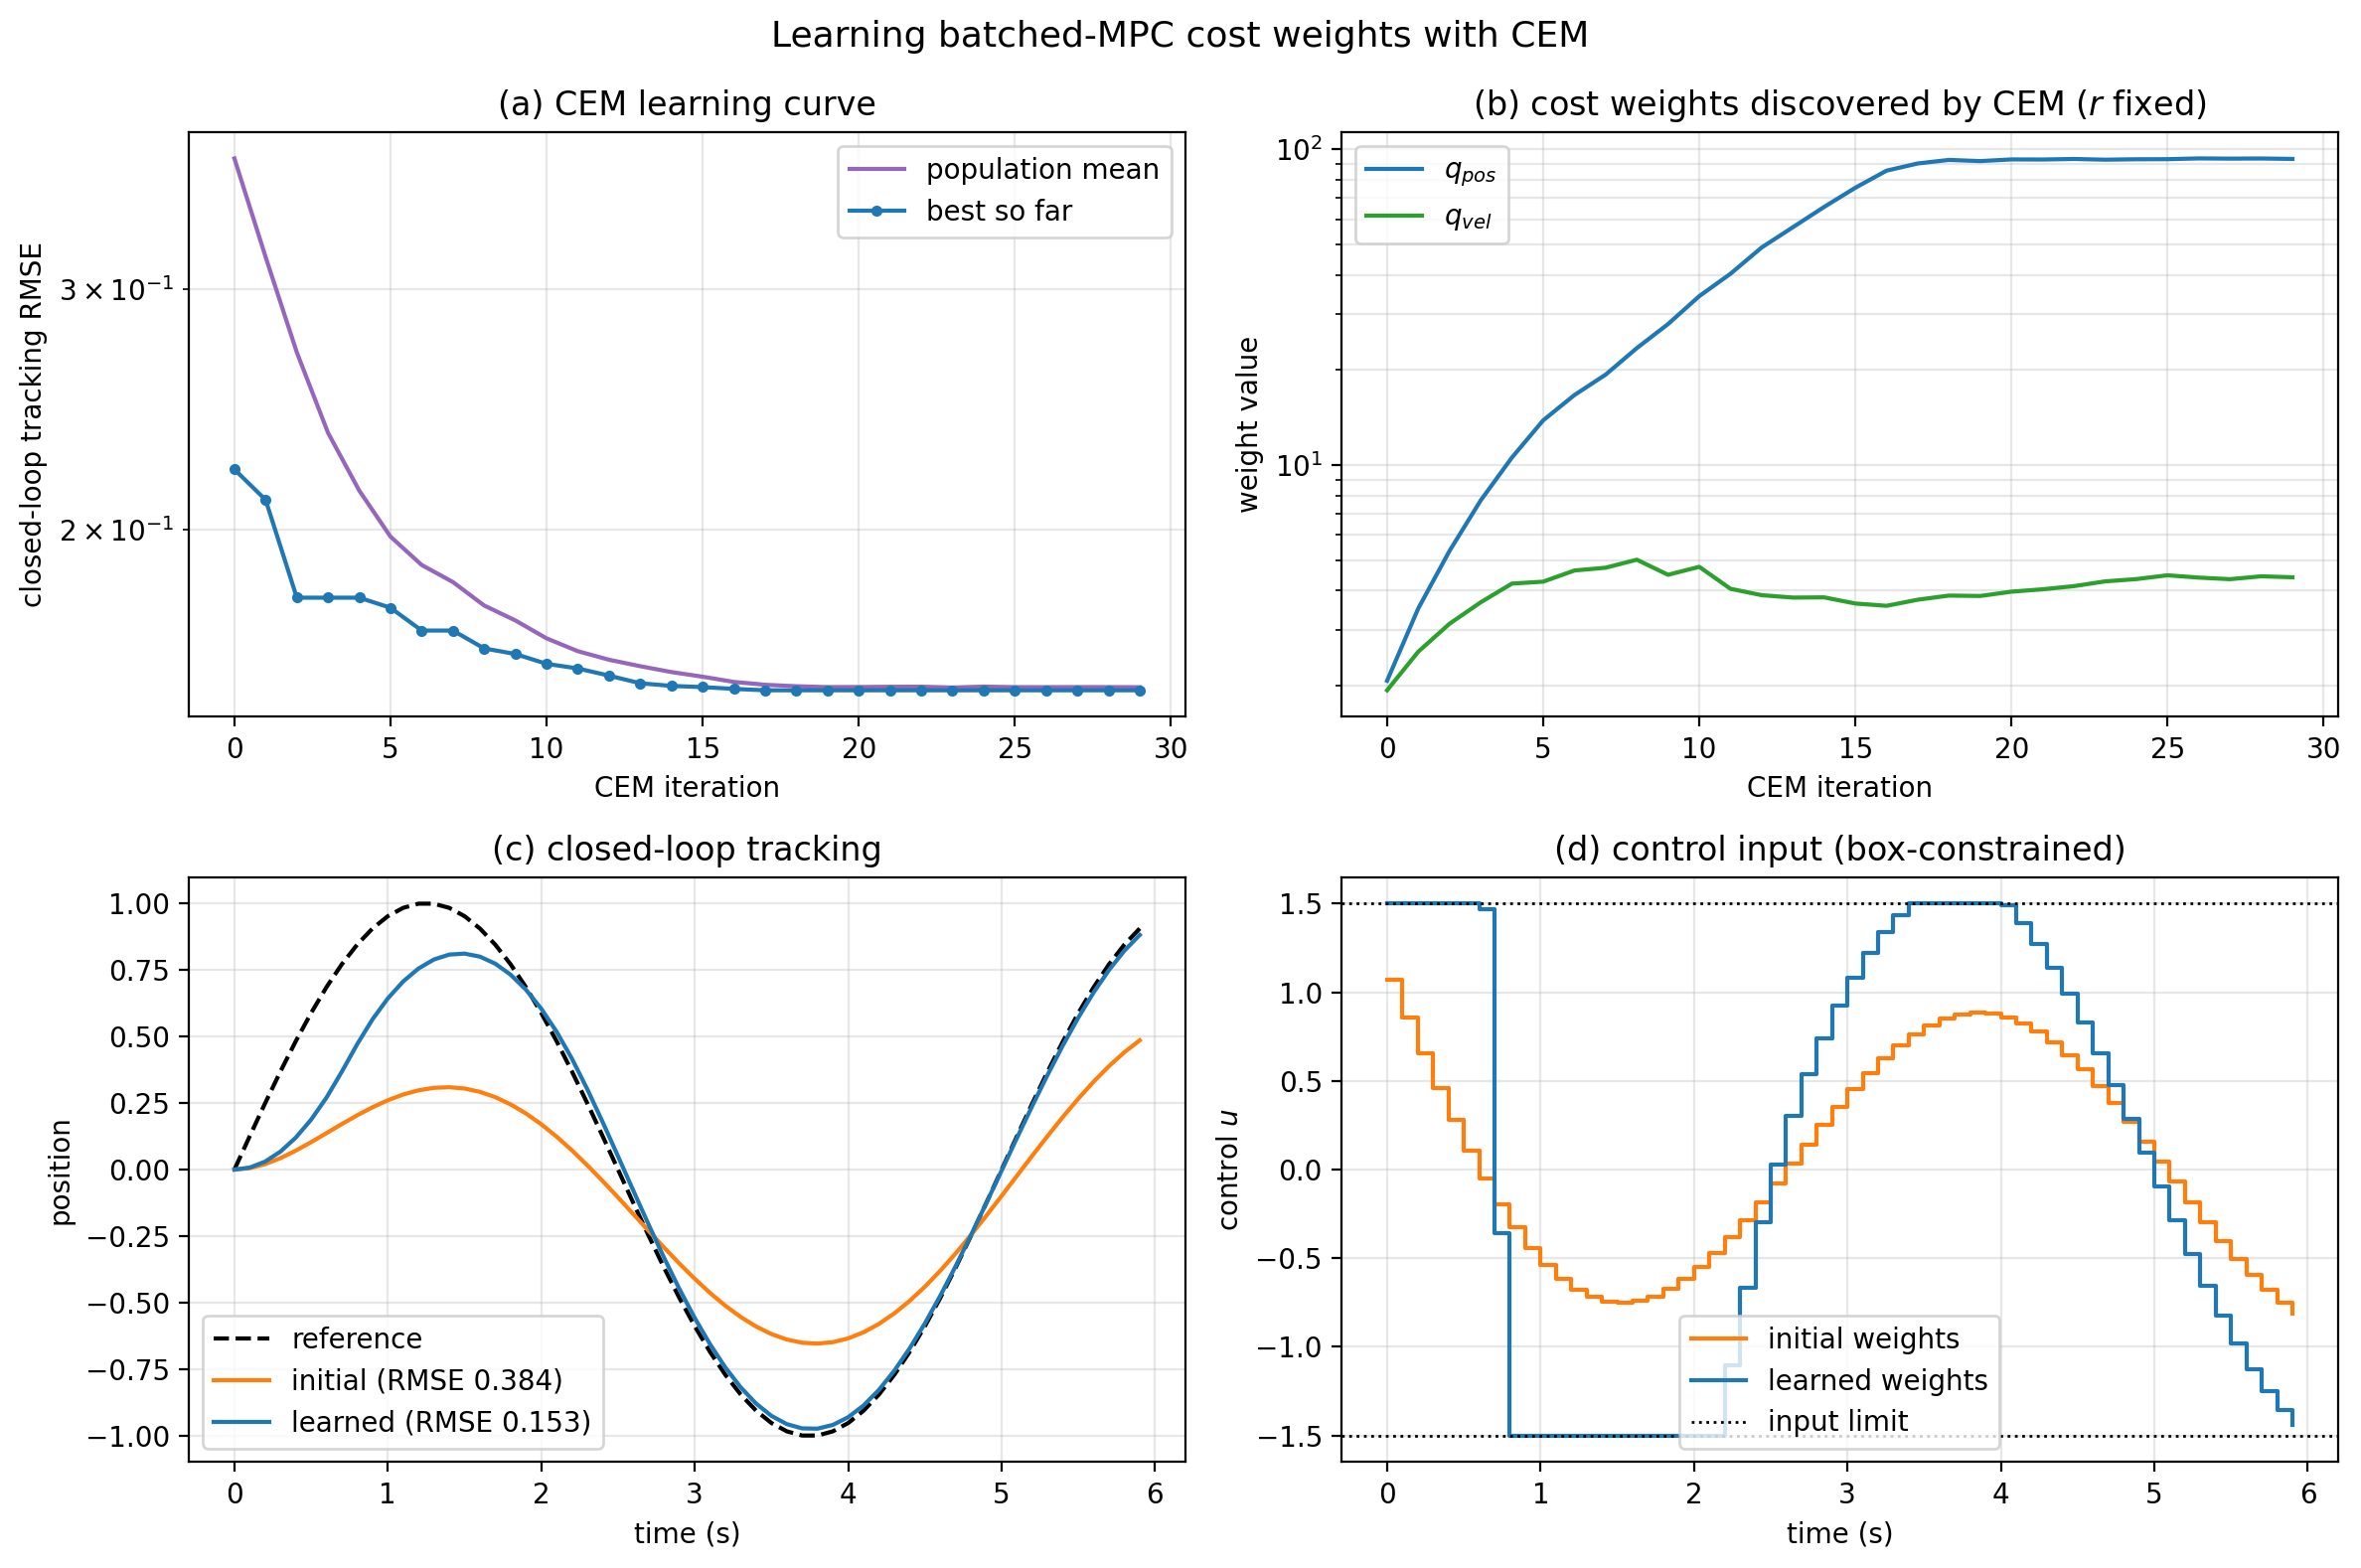

Initial weights (q_pos, q_vel): (1.00, 1.00)
Learned weights (q_pos, q_vel): (93.10, 4.41)
Tracking RMSE: 0.3838 -> 0.1531


In [5]:
# Compare initial weights (1, 1) against the learned ones in a single batch of two rollouts.
comparison = np.vstack([np.ones(2), learned_weights])
_, rmse, positions, controls = BatchedMPC(2).rollout(comparison, record=True)

tgrid = np.arange(T) * DT
gens = np.arange(len(history))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) CEM learning curve.
ax = axes[0, 0]
ax.plot(gens, history[:, 1], color="#9467bd", label="population mean")
ax.plot(gens, np.minimum.accumulate(history[:, 0]), "o-", color="#1f77b4", ms=3,
        label="best so far")
ax.set_xlabel("CEM iteration"); ax.set_ylabel("closed-loop tracking RMSE")
ax.set_yscale("log"); ax.set_title("(a) CEM learning curve")
ax.grid(alpha=0.3, which="both"); ax.legend()

# (b) Distribution-mean cost weights discovered by CEM (r fixed).
ax = axes[0, 1]
ax.plot(gens, history[:, 2], color="#1f77b4", label=r"$q_{pos}$")
ax.plot(gens, history[:, 3], color="#2ca02c", label=r"$q_{vel}$")
ax.set_xlabel("CEM iteration"); ax.set_ylabel("weight value")
ax.set_yscale("log"); ax.set_title(r"(b) cost weights discovered by CEM ($r$ fixed)")
ax.grid(alpha=0.3, which="both"); ax.legend()

# (c) Position tracking: reference vs initial vs learned weights.
ax = axes[1, 0]
ax.plot(tgrid, cp.asnumpy(problem["ref_pos"]), "k--", lw=1.5, label="reference")
ax.plot(tgrid, positions[:, 0], color="#ff7f0e", label=f"initial (RMSE {rmse[0]:.3f})")
ax.plot(tgrid, positions[:, 1], color="#1f77b4", label=f"learned (RMSE {rmse[1]:.3f})")
ax.set_xlabel("time (s)"); ax.set_ylabel("position")
ax.set_title("(c) closed-loop tracking"); ax.grid(alpha=0.3); ax.legend()

# (d) Control input: piecewise-constant over each step, so drawn as a step plot.
ax = axes[1, 1]
ax.step(tgrid, controls[:, 0], where="post", color="#ff7f0e", label="initial weights")
ax.step(tgrid, controls[:, 1], where="post", color="#1f77b4", label="learned weights")
ax.axhline(+U_MAX, color="k", ls=":", lw=1)
ax.axhline(-U_MAX, color="k", ls=":", lw=1, label="input limit")
ax.set_xlabel("time (s)"); ax.set_ylabel("control $u$")
ax.set_title("(d) control input (box-constrained)"); ax.grid(alpha=0.3); ax.legend()

fig.suptitle("Learning batched-MPC cost weights with CEM", fontsize=13)
fig.tight_layout(); plt.show()

print(f"Initial weights (q_pos, q_vel): ({comparison[0, 0]:.2f}, {comparison[0, 1]:.2f})")
print(f"Learned weights (q_pos, q_vel): ({learned_weights[0]:.2f}, {learned_weights[1]:.2f})")
print(f"Tracking RMSE: {rmse[0]:.4f} -> {rmse[1]:.4f}")